# Figure1_1

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure1")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.plotting import set_paper_theme

set_paper_theme(tick_width=0.3)


## Panel C — Example trajectories

In [3]:

task, monkey = "animate_vs_inanimate", "Judy"
data,files = loadTrialsM(task,monkey,verbose=True,islearn=False,extend=False)

targ_size1 = data[0][0]["targ_pos"][0,2]
targ_size2 = data[0][0]["targ_pos"][0,3]
targ_pos1 = data[0][0]["targ_pos"][0,:2]
targ_pos2 = data[0][0]["targ_pos"][1,:2]


data_behavior/Monkey/animate_vs_inanimate/Judy20230512_01_fmt.mat Trials Num:552
data_behavior/Monkey/animate_vs_inanimate/Judy20230513_01_fmt.mat Trials Num:852
data_behavior/Monkey/animate_vs_inanimate/Judy20230515_01_fmt.mat Trials Num:772
data_behavior/Monkey/animate_vs_inanimate/Judy20230516_01_fmt.mat Trials Num:647
data_behavior/Monkey/animate_vs_inanimate/Judy20230517_01_fmt.mat Trials Num:693
data_behavior/Monkey/animate_vs_inanimate/Judy20230518_01_fmt.mat Trials Num:755


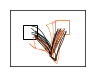

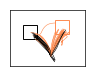

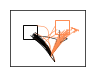

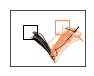

In [4]:
for day in range(4):
    trials = data[day]
    targ1 = plt.Rectangle(xy=(targ_pos1[0]-targ_size1/2, targ_pos1[1]-targ_size2/2), width=targ_size1 , height=targ_size2, linewidth=0.7,facecolor='None',edgecolor="#FD8B51")
    targ2 = plt.Rectangle(xy=(targ_pos2[0]-targ_size1/2, targ_pos2[1]-targ_size2/2), width=targ_size1 , height=targ_size2, linewidth=0.7,facecolor='None',edgecolor='black')
    fig,ax = plt.subplots()
    fig.set(figheight=42/75,figwidth=56/75)
    ax.add_patch(targ1)
    ax.add_patch(targ2)
    ax.set_xlim([-24,24])
    ax.set_ylim([-18,18])
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_position([0,0,1,1])
    for i in np.random.choice(range(len(trials)),50,replace=False):
        trial = trials[i]
        object_data = trial["object_data"]
        object_data = object_data[np.isnan(object_data)==False].reshape(-1,4)
        object_data = object_data[object_data[:,2]==1,:]
        if trial["targ_cat_ID"][trial["targ_cor"]-1]==1:
            ax.plot(object_data[:,0],object_data[:,1],linewidth=0.4,color="#FD8B51")
        else:
            ax.plot(object_data[:,0],object_data[:,1],linewidth=0.4,color='black')
    plt.savefig(FIGURE_OUTPUT_DIR / f"monkey_trajectory_day_{day}.pdf")
    plt.show()